In [1]:
import json
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('../..')
from style_setup import set_thesis_style
set_thesis_style()


In [5]:
data_paths = {
    "Single source": "/Users/maxschaffelder/Desktop/Thesis/data/exp_3/absolute/outputs/small/llama_8b_single_source.jsonl",
    "Multi source": "/Users/maxschaffelder/Desktop/Thesis/data/exp_3/absolute/outputs/small/llama_8b_multi_source.jsonl",
    "Human source": "/Users/maxschaffelder/Desktop/Thesis/data/exp_3/absolute/outputs/small/llama_8b_human_source.jsonl",
    "Vanilla": "/Users/maxschaffelder/Desktop/Thesis/data/exp_3/absolute/outputs/small/llama_8b_vanilla.jsonl"
}

scores = {}

for source, path in data_paths.items():
    with open(path, 'r') as f:
        data = [line for line in f]
    
    scores[source] = []
    for i, line in enumerate(data):
        scores[source].append(json.loads(line))




In [6]:
single_source_scores = {}
for i, line in enumerate(scores["Single source"]):
    model_name = line["model_name"]
    if model_name not in single_source_scores:
        single_source_scores[model_name] = []

    weighted_score = 0
    for rating, prob in line["token_probabilities"][0]["target_probs"].items():
        weighted_score += int(rating) * prob

    single_source_scores[model_name].append(weighted_score)

multi_source_scores = {}
for i, line in enumerate(scores["Multi source"]):
    model_name = line["model_name"]
    if model_name not in multi_source_scores:
        multi_source_scores[model_name] = []

    weighted_score = 0
    for rating, prob in line["token_probabilities"][0]["target_probs"].items():
        weighted_score += int(rating) * prob

    multi_source_scores[model_name].append(weighted_score)

human_source_scores = {}
for i, line in enumerate(scores["Human source"]):
    model_name = line["model_name"]
    if model_name not in human_source_scores:
        human_source_scores[model_name] = []

    weighted_score = 0
    for rating, prob in line["token_probabilities"][0]["target_probs"].items():
        weighted_score += int(rating) * prob

    human_source_scores[model_name].append(weighted_score)

vanilla_scores = {}
for i, line in enumerate(scores["Vanilla"]):
    model_name = line["model_name"]
    if model_name not in vanilla_scores:
        vanilla_scores[model_name] = []

    weighted_score = 0
    for rating, prob in line["token_probabilities"][0]["target_probs"].items():
        weighted_score += int(rating) * prob

    vanilla_scores[model_name].append(weighted_score)


In [7]:
# Create a dictionary with the mean scores for each model and source
data = {
    'llama': [
        np.mean(single_source_scores['llama']),
        np.mean(multi_source_scores['llama']),
        np.mean(human_source_scores['llama']),
        np.mean(vanilla_scores['llama'])
    ],
    'qwen': [
        np.mean(single_source_scores['qwen']),
        np.mean(multi_source_scores['qwen']),
        np.mean(human_source_scores['qwen']),
        np.mean(vanilla_scores['qwen'])
    ],
    'falcon': [
        np.mean(single_source_scores['falcon']),
        np.mean(multi_source_scores['falcon']),
        np.mean(human_source_scores['falcon']),
        np.mean(vanilla_scores['falcon'])
    ],
    'gemma': [
        np.mean(single_source_scores['gemma']),
        np.mean(multi_source_scores['gemma']),
        np.mean(human_source_scores['gemma']),
        np.mean(vanilla_scores['gemma'])
    ],
    'human': [
        np.mean(single_source_scores['human']),
        np.mean(multi_source_scores['human']),
        np.mean(human_source_scores['human']),
        np.mean(vanilla_scores['human'])
    ]
}

# Create DataFrame with specified index
df = pd.DataFrame(data, index=['Single source', 'Multi source', 'Human source', 'Vanilla'])
df.to_csv('/Users/maxschaffelder/Desktop/Thesis/data/exp_3/absolute/outputs/small/llama_8b_mean_scores.csv')
df.head(10)


,llama,qwen,falcon,gemma,human
Single source,4.044105,3.971402,3.923135,3.921624,3.318840
Multi source,4.390315,4.317917,4.264835,4.277153,3.786430
Human source,4.111813,4.106027,4.052482,4.079050,3.650149
Vanilla,3.979249,3.901087,3.863736,3.826862,3.321119


# Plot

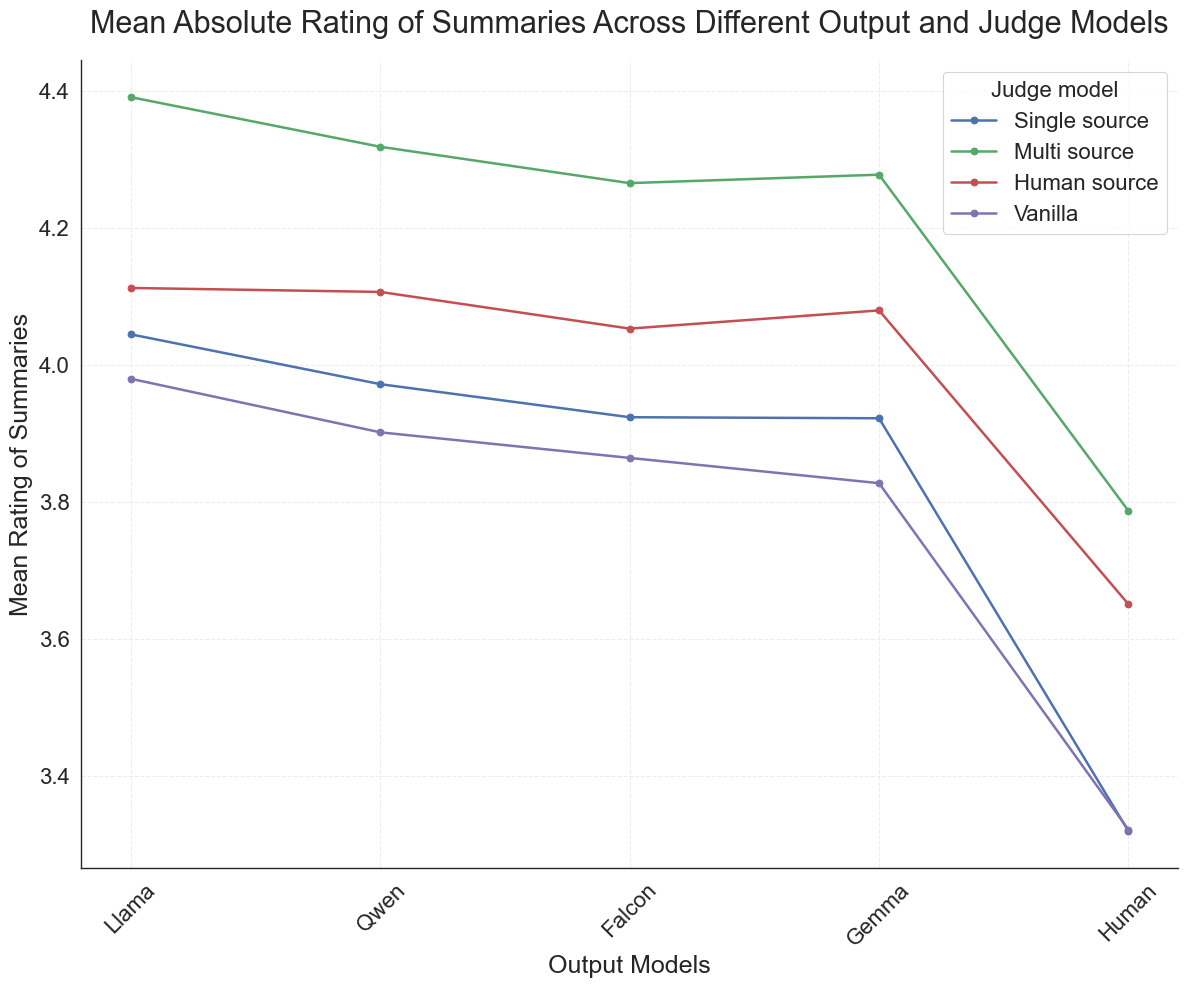

In [8]:
plt.figure(figsize=(12, 10))
for idx, row in df.iterrows():
    plt.plot(df.columns, row.values, marker='o', label=idx)

plt.xlabel('Output Models', fontsize=18)
plt.ylabel('Mean Rating of Summaries', fontsize=18)
plt.title('Mean Absolute Rating of Summaries Across Different Output and Judge Models', fontsize=22, pad=20)
plt.legend(fontsize=16, title="Judge model", title_fontsize=16)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(ticks=range(len(df.columns)), labels=[col.capitalize() for col in df.columns], rotation=45, fontsize=16)
plt.yticks(fontsize=16)
plt.tight_layout()
#plt.savefig('/Users/maxschaffelder/Desktop/Thesis/plots/exp_3/line_abs_ratings_v3.png')
plt.show()


# Significance testing

In [26]:
llama_scores = {}
qwen_scores = {}
falcon_scores = {}
gemma_scores = {}
human_scores = {}

for name, variable in [("single_source", single_source_scores), ("multi_source", multi_source_scores), ("human_source", human_source_scores), ("vanilla", vanilla_scores)]:
    llama_scores[name] = [score for score in variable["llama"]]
    qwen_scores[name] = [score for score in variable["qwen"]]
    falcon_scores[name] = [score for score in variable["falcon"]]
    gemma_scores[name] = [score for score in variable["gemma"]]
    human_scores[name] = [score for score in variable["human"]]
    

In [34]:
len(score_dict["llama_scores"]["single_source"])

100

In [28]:
score_dict = {
    "llama_scores": llama_scores,
    "qwen_scores": qwen_scores,
    "falcon_scores": falcon_scores,
    "gemma_scores": gemma_scores,
    "human_scores": human_scores,
}




for name, score_data in score_dict.items():
    print("----------------------------------------------------")
    print(f"{name}:")
    # Perform Kruskal-Wallis H-test (non-parametric ANOVA) to test if distributions are significantly different
    groups = [scores for condition, scores in score_data.items()] 
    H, p_value = stats.kruskal(*groups)

    dataset_names = [condition for condition, scores in score_data.items()] 

    print(f"Kruskal-Wallis H-test results:")
    print(f"H-statistic: {H:.2f}")
    print(f"p-value: {p_value:.2e}")

    # If significant, perform pairwise Mann-Whitney U tests with Bonferroni correction
    if p_value < 0.05:
        print("\nPairwise comparisons (Mann-Whitney U test with Bonferroni correction):")
        n_comparisons = len(dataset_names) * (len(dataset_names) - 1) // 2
        alpha = 0.05 / n_comparisons  # Bonferroni correction
        
        for i in range(len(dataset_names)):
            for j in range(i + 1, len(dataset_names)):
                stat, p = stats.mannwhitneyu(groups[i], groups[j], alternative='two-sided')
                print(f"\n{dataset_names[i]} vs {dataset_names[j]}:")
                print(f"U-statistic: {stat:.2f}")
                print(f"p-value: {p:.2e}")
                print(f"Significant difference: {'Yes' if p < alpha else 'No'}")



----------------------------------------------------
llama_scores:
Kruskal-Wallis H-test results:
H-statistic: 2.70
p-value: 4.40e-01
----------------------------------------------------
qwen_scores:
Kruskal-Wallis H-test results:
H-statistic: 3.31
p-value: 3.47e-01
----------------------------------------------------
falcon_scores:
Kruskal-Wallis H-test results:
H-statistic: 3.62
p-value: 3.06e-01
----------------------------------------------------
gemma_scores:
Kruskal-Wallis H-test results:
H-statistic: 1.67
p-value: 6.44e-01
----------------------------------------------------
human_scores:
Kruskal-Wallis H-test results:
H-statistic: 2.30
p-value: 5.13e-01
